# Positive and Negative Predictive values of CITE Seq ABs

In [1]:
%load_ext autoreload
%matplotlib inline

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore')
import os
import scanpy as sc
import scirpy as ir
import anndata as ann
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mudata import MuData
import mudata

import tarfile
import warnings
from glob import glob

import anndata
import matplotlib.pyplot as plt
import muon as mu
import pandas as pd
import scanpy as sc
import scirpy as ir

%autoreload 2
import sys
sys.path.append('../3_scRNA-Seq_Sina')
import utility.annotation as utils_annotation
import utility.representation as utils_representation
import utility.visualisation as utils_vis

from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

In [2]:
sc.settings.set_figure_params(dpi=150)
sc.settings.verbosity = 3
sc.set_figure_params(vector_friendly=True, color_map='viridis', transparent=True)
sb.set_style('whitegrid')

colormap = 'flare'

In [3]:
kdata = mu.read(f"./data_id_annotated_citeseq.h5ad")

In [4]:
#preserve leiden information and clone_id
kdata.obs['leiden_kdata'] = kdata.obs['leiden']
kdata.obs['clone_id_kdata'] = kdata.obs['clone_id_m']

In [5]:
kdata = kdata[kdata.obs['celltype']=='CD8']

In [6]:
sdata = mu.read(f"/media/agschober/HDD15/Mimi/3_scRNA-Seq_Sina/data_merged_annotated_specificity_cite.h5mu")

In [7]:
#preserve leiden information and clone_id
sdata['gex'].obs['leiden_sdata'] = sdata['gex'].obs['leiden']
sdata['gex'].obs['clone_id_sdata'] = sdata['gex'].obs['clone_id']

In [8]:
sdata.mod['gex'] = anndata.concat([sdata.mod['gex'], kdata], join='outer', label='batch', keys=['existing_gex', 'new_kdata'])
sdata.mod['gex'].obs['dataset'] = ['existing_gex'] * sdata.mod['gex'][:len(sdata.mod['gex']) - len(kdata)].shape[0] + ['new_kdata'] * kdata.shape[0]

In [9]:
sc.pp.normalize_total(sdata.mod['gex'])
sc.pp.log1p(sdata.mod['gex'])

normalizing counts per cell
    finished (0:00:00)


In [10]:
sc.pp.combat(sdata['gex'], key='dataset')

Standardizing Data across genes.

Found 2 batches

Found 0 numerical variables:
	

Found 12269 genes with zero variance.
Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting data



In [11]:
for key in ['X_umap', 'X_diffmap', 'X_pca']:
    if key in sdata.mod['gex'].obsm.keys():
        del sdata.mod['gex'].obsm[key]

for key in ['neighbors', 'diffmap', 'paga']:
    if key in sdata.mod['gex'].uns:
        del sdata.mod['gex'].uns[key]
    for sub_key in list(sdata.mod['gex'].obsp.keys()):
        if key in sub_key:
            del sdata.mod['gex'].obsp[sub_key]

In [12]:
#recalculate the umap and plot again
utils_representation.calculate_umap(sdata['gex'], n_high_var=5000, remove_tcr_genes=True)

extracting highly variable genes
    finished (0:00:50)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing neighbors
         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA
    with n_comps=50
    finished (0:00:21)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:47)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:40)


In [13]:
utils_representation.calculate_leiden(sdata["gex"], resolution=1.0, n_high_var=5000, remove_tcr_genes=True)

extracting highly variable genes
    finished (0:00:50)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing neighbors
         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA
    with n_comps=50
    finished (0:00:20)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:29)
running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:18)


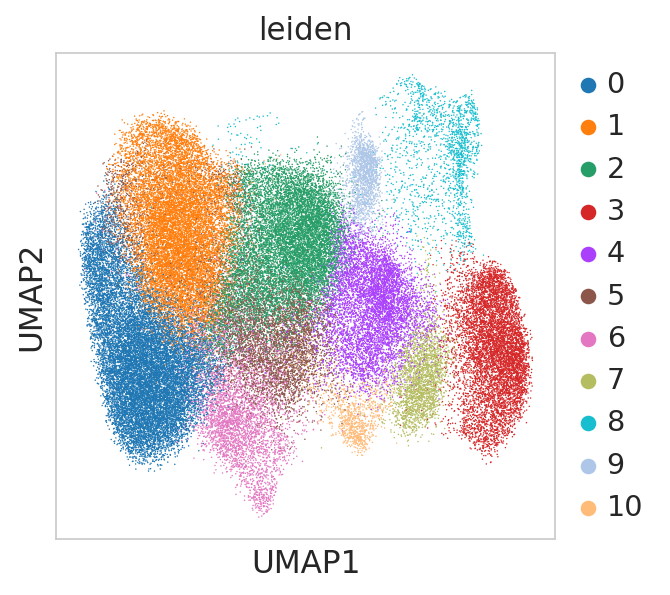

In [14]:
sc.pl.umap(sdata["gex"], color='leiden')

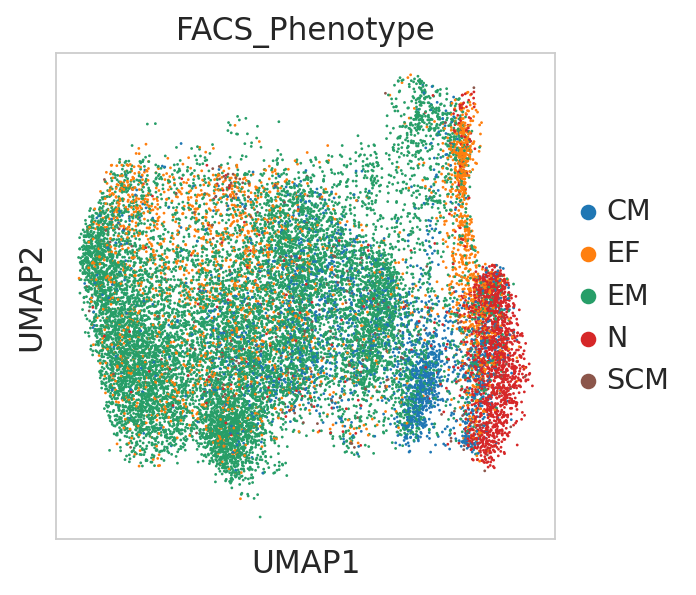

In [32]:
sc.pl.umap(sdata["gex"][sdata['gex'].obs['FACS_Phenotype']!='NONE'], color='FACS_Phenotype')

In [15]:
pal = {'CD4': 'lightgrey',
      'NONE': 'lightgrey', 'N': '#CCCCCC',
      'SCM': 'red', 
      'CM': '#004182',
      'EM': '#008282',
      'EF': '#00AC00'}

#'#86C3FF'

In [16]:
#regate the part of sinas data
#annotation of Phenotype according to "FACS" for every cell - new annotation
sdata["gex"].obs['CD45RA+s'][sdata['gex'].obs['dataset']=='existing_gex'] = sdata["gex"].obs['clr_CD45RA'].apply(lambda x: 1 if x>=1.4 else 0)
sdata["gex"].obs['CD62L+s'][sdata['gex'].obs['dataset']=='existing_gex'] = sdata["gex"].obs['clr_CD62L'].apply(lambda x: 1 if x>=2 else 0)
sdata["gex"].obs['CD95+s'][sdata['gex'].obs['dataset']=='existing_gex'] = sdata["gex"].obs['clr_CD95'].apply(lambda x: 1 if x>=0.7 else 0)

sdata["gex"].obs['FACS_Phenotype'][sdata['gex'].obs['dataset']=='existing_gex'] = 'NONE'

for i in range(len(sdata["gex"].obs[sdata['gex'].obs['dataset']=='existing_gex'])):
    if ((sdata["gex"].obs['CD45RA+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==1) & (sdata["gex"].obs['CD62L+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==0)):
        sdata["gex"].obs['FACS_Phenotype'][i] = 'EF'
    else:
        if ((sdata["gex"].obs['CD45RA+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==0) & (sdata["gex"].obs['CD62L+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==0)):
            sdata["gex"].obs['FACS_Phenotype'][i] = 'EM'
        else:
            if ((sdata["gex"].obs['CD45RA+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==0) & (sdata["gex"].obs['CD62L+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==1)):
                sdata["gex"].obs['FACS_Phenotype'][i] = 'CM'
            else:
                if ((sdata["gex"].obs['CD45RA+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==1) & (sdata["gex"].obs['CD62L+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==1) & (sdata["gex"].obs['CD95+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==1)):
                    sdata["gex"].obs['FACS_Phenotype'][i] = 'SCM'
                else:
                    if ((sdata["gex"].obs['CD45RA+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==1) & (sdata["gex"].obs['CD62L+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==1) & (sdata["gex"].obs['CD95+s'][sdata['gex'].obs['dataset']=='existing_gex'][i]==0)):
                        sdata["gex"].obs['FACS_Phenotype'][i] = 'N'
                    else:
                        sdata["gex"].obs['FACS_Phenotype'][i] = 'NONE'

In [17]:
custom_cite_ids = ['Hu.CD101', 'Hu.CD103', 'Hu.CD105_43A3', 'Hu.CD107a', 'Hu.CD112', 'Hu.CD119', 'Hu.CD11a', 
                   'Hu.CD11b', 'Hu.CD11c', 'Hu.CD122', 'Hu.CD123', 'Hu.CD124', 'Hu.CD127', 'Hu.CD13', 'Hu.CD134', 
                   'Hu.CD137', 'Hu.CD141', 'Hu.CD146', 'Hu.CD14_M5E2', 'Hu.CD152', 'Hu.CD154', 'Hu.CD155', 
                   'Hu.CD158', 'Hu.CD158b', 'Hu.CD158e1', 'Hu.CD16', 'Hu.CD161', 'Hu.CD163', 'Hu.CD169', 
                   'Hu.CD18', 'Hu.CD183', 'Hu.CD185', 'Hu.CD19', 'Hu.CD194', 'Hu.CD195', 'Hu.CD196', 'Hu.CD1c', 
                   'Hu.CD1d', 'Hu.CD2', 'Hu.CD20_2H7', 'Hu.CD21', 'Hu.CD22', 'Hu.CD223', 'Hu.CD224', 
                   'Hu.CD226_11A8', 'Hu.CD23', 'Hu.CD24', 'Hu.CD244', 'Hu.CD25', 'Hu.CD26', 'Hu.CD267', 'Hu.CD268',
                   'Hu.CD27', 'Hu.CD270', 'Hu.CD272', 'Hu.CD274', 'Hu.CD279', 'Hu.CD28', 'Hu.CD29', 'Hu.CD303', 
                   'Hu.CD31', 'Hu.CD314', 'Hu.CD319', 'Hu.CD32', 'Hu.CD328', 'Hu.CD33', 'Hu.CD335', 'Hu.CD35', 
                   'Hu.CD352', 'Hu.CD36', 'Hu.CD38_HIT2', 'Hu.CD39', 'Hu.CD3_UCHT1', 'Hu.CD40', 'Hu.CD41', 
                   'Hu.CD42b', 'Hu.CD45RA', 'Hu.CD45RO', 'Hu.CD45_HI30', 'Hu.CD47', 'Hu.CD48', 'Hu.CD49a', 
                   'Hu.CD49b', 'Hu.CD49d', 'Hu.CD4_RPA.T4', 'Hu.CD5', 'Hu.CD52', 'Hu.CD54', 'Hu.CD56', 'Hu.CD57', 
                   'Hu.CD58', 'Hu.CD62L', 'Hu.CD62P', 'Hu.CD64', 'Hu.CD69', 'Hu.CD7', 'Hu.CD71', 'Hu.CD73', 
                   'Hu.CD79b', 'Hu.CD8', 'Hu.CD81', 'Hu.CD82', 'Hu.CD83', 'Hu.CD85j', 'Hu.CD86', 'Hu.CD88', 
                   'Hu.CD94', 'Hu.CD95', 'Hu.CD99', 'Hu.CLEC12A', 'Hu.CX3CR1', 'Hu.FceRIa', 'Hu.GPR56', 
                   'Hu.HLA.ABC', 'Hu.HLA.DR', 'Hu.HLA.E', 'Hu.Ig.LightChain.k', 'Hu.Ig.LightChain.l', 'Hu.IgD', 
                   'Hu.IgM', 'Hu.KLRG1', 'Hu.LOX.1', 'Hu.TCR.AB', 'Hu.TCR.Va7.2', 'Hu.TCR.Vd2', 'Hu.TIGIT', 
                   'HuMs.CD44', 'HuMs.CD49f', 'HuMs.integrin.b7', 'HuMsRt.CD278', 'Isotype_HTK888', 
                   'Isotype_MOPC.173', 'Isotype_MOPC.21', 'Isotype_MPC.11', 'Isotype_RTK2071', 'Isotype_RTK2758', 
                   'Isotype_RTK4530']

## Look how good the individual markers are

In [33]:
#create naive column
sdata['gex'].obs['naive']=False
sdata['gex'].obs['naive'][sdata['gex'].obs['leiden']=='3'] = True

In [34]:
#subset sdata to only look in the cells that have the markers
sdata_tmp = sdata['gex'][sdata['gex'].obs['clr_Hu.CD95'].notna()]

In [35]:
marker_results = pd.DataFrame(columns=['marker_name', 'optimal_cutoff', 'sensitivity_at_optimal', 
                                       'specificity_at_optimal', 'PPV_at_cutoff', 'NPV_at_cutoff'])
marker_results_list = []

for marker_name in custom_cite_ids:
    # Generate 100 cutoffs within the range of the marker
    min_marker = sdata['gex'].obs['clr_'+str(marker_name)].min()
    max_marker = sdata['gex'].obs['clr_'+str(marker_name)].max()
    cutoffs = np.linspace(min_marker, max_marker, 100)

    sensitivities = []
    specificities = []
    PPVs = []
    NPVs = []

    # Calculate sensitivity and specificity for each cutoff
    for cutoff in cutoffs:
        # Predicted positives and negatives based on the cutoff
        predictions = sdata['gex'].obs['clr_'+str(marker_name)] <= cutoff

        # Calculate confusion matrix
        tn, fp, fn, tp = confusion_matrix(sdata['gex'].obs['naive'], predictions).ravel()

        # Calculate sensitivity and specificity
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        PPV = tp / (tp+fp)
        NPV = tn / (tn+fn)

        sensitivities.append(sensitivity)
        specificities.append(specificity)
        PPVs.append(PPV)
        NPVs.append(NPV)
        
    # Convert results to DataFrame for easier analysis
    results = pd.DataFrame({
        'cutoff': cutoffs,
        'sensitivity': sensitivities,
        'specificity': specificities,
        'PPV': PPVs,
        'NPV': NPVs
    })

    # Finding the cutoff that maximizes Youden's J statistic
    results['youden_j'] = results['sensitivity'] + results['specificity'] - 1
    optimal_cutoff = results.loc[results['youden_j'].idxmax()]

    marker_results_list.append(pd.DataFrame({
        'marker_name': [marker_name],
        'optimal_cutoff': [optimal_cutoff['cutoff']],
        'sensitivity_at_optimal': [optimal_cutoff['sensitivity']],
        'specificity_at_optimal': [optimal_cutoff['specificity']],
        'PPV_at_cutoff': [optimal_cutoff['PPV']],
        'NPV_at_cutoff': [optimal_cutoff['NPV']]
    }))

# Concatenate the list of DataFrames into one DataFrame
marker_results = pd.concat(marker_results_list, ignore_index=True)

In [36]:
marker_results.to_csv('CITE-Seq_marker_PPV_NPV_negative_filtered_cells.csv')

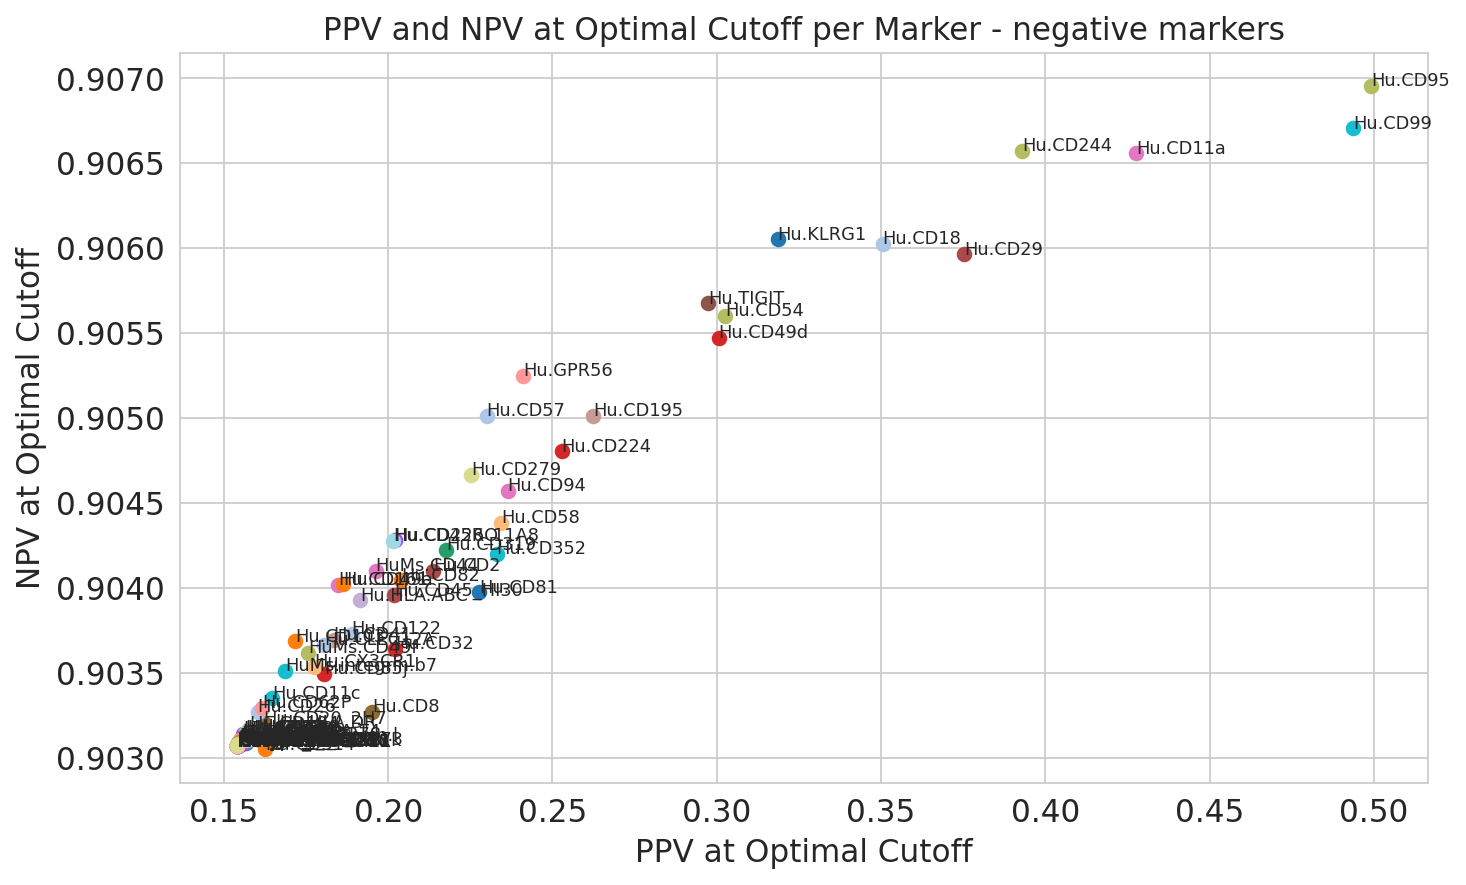

In [37]:
plt.figure(figsize=(10, 6))
for index, row in marker_results.iterrows():
    plt.scatter(row['PPV_at_cutoff'], row['NPV_at_cutoff'], label=row['marker_name'])
    plt.text(row['PPV_at_cutoff'], row['NPV_at_cutoff'], row['marker_name'], fontsize=8)
plt.xlabel('PPV at Optimal Cutoff')
plt.ylabel('NPV at Optimal Cutoff')
plt.title('PPV and NPV at Optimal Cutoff per Marker - negative markers')
#plt.savefig(f'Exports/Marker_negative_filtered_cells.pdf', dpi=1200)
plt.show()

In [38]:
marker_results = pd.DataFrame(columns=['marker_name', 'optimal_cutoff', 'sensitivity_at_optimal', 
                                       'specificity_at_optimal', 'PPV_at_cutoff', 'NPV_at_cutoff'])
marker_results_list = []

for marker_name in custom_cite_ids:
    # Generate 100 cutoffs within the range of the marker
    min_marker = sdata_tmp.obs['clr_'+str(marker_name)].min()
    max_marker = sdata_tmp.obs['clr_'+str(marker_name)].max()
    cutoffs = np.linspace(min_marker, max_marker, 100)

    sensitivities = []
    specificities = []
    PPVs = []
    NPVs = []

    # Calculate sensitivity and specificity for each cutoff
    for cutoff in cutoffs:
        # Predicted positives and negatives based on the cutoff
        predictions = sdata_tmp.obs['clr_'+str(marker_name)] >= cutoff

        # Calculate confusion matrix
        tn, fp, fn, tp = confusion_matrix(sdata_tmp.obs['naive'], predictions).ravel()

        # Calculate sensitivity and specificity
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        PPV = tp / (tp+fp)
        NPV = tn / (tn+fn)

        sensitivities.append(sensitivity)
        specificities.append(specificity)
        PPVs.append(PPV)
        NPVs.append(NPV)
        
    # Convert results to DataFrame for easier analysis
    results = pd.DataFrame({
        'cutoff': cutoffs,
        'sensitivity': sensitivities,
        'specificity': specificities,
        'PPV': PPVs,
        'NPV': NPVs
    })

    # Finding the cutoff that maximizes Youden's J statistic
    results['youden_j'] = results['sensitivity'] + results['specificity'] - 1
    optimal_cutoff = results.loc[results['youden_j'].idxmax()]

    marker_results_list.append(pd.DataFrame({
        'marker_name': [marker_name],
        'optimal_cutoff': [optimal_cutoff['cutoff']],
        'sensitivity_at_optimal': [optimal_cutoff['sensitivity']],
        'specificity_at_optimal': [optimal_cutoff['specificity']],
        'PPV_at_cutoff': [optimal_cutoff['PPV']],
        'NPV_at_cutoff': [optimal_cutoff['NPV']]
    }))

# Concatenate the list of DataFrames into one DataFrame
marker_results = pd.concat(marker_results_list, ignore_index=True)

In [39]:
marker_results.to_csv('CITE-Seq_marker_PPV_NPV_positive_filtered_cells.csv')

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

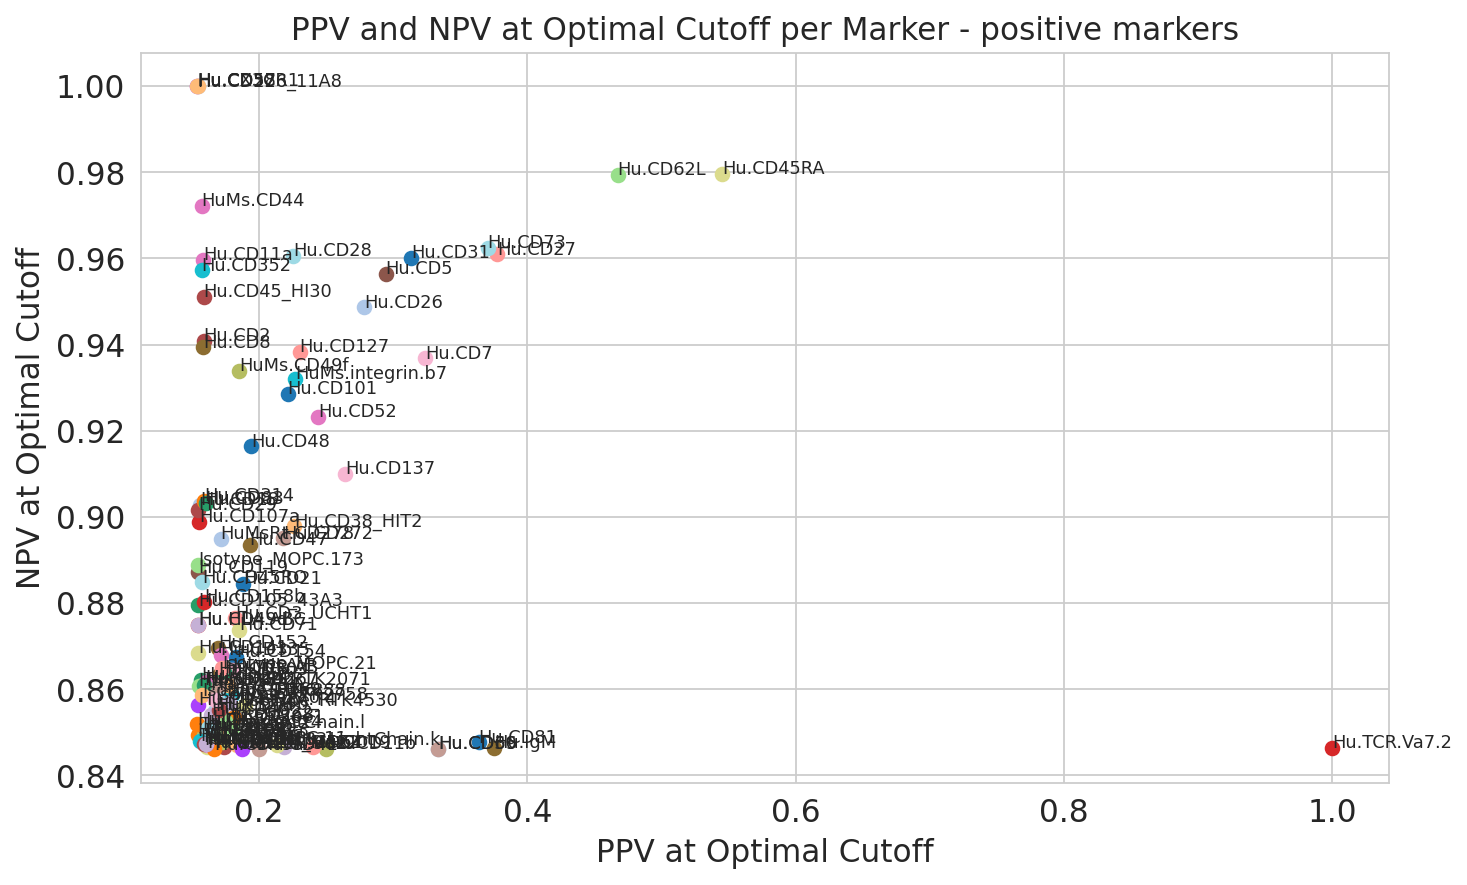

In [40]:
plt.figure(figsize=(10, 6))
for index, row in marker_results.iterrows():
    plt.scatter(row['PPV_at_cutoff'], row['NPV_at_cutoff'], label=row['marker_name'])
    plt.text(row['PPV_at_cutoff'], row['NPV_at_cutoff'], row['marker_name'], fontsize=8)
plt.xlabel('PPV at Optimal Cutoff')
plt.ylabel('NPV at Optimal Cutoff')
plt.title('PPV and NPV at Optimal Cutoff per Marker - positive markers')
plt.savefig(f'Exports/Marker_positive_filtered_cells.pdf', dpi=1200)
plt.show()